In [ ]:
import os
import glob
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.metrics import classification_report

# import tensorflow, keras, scikit_learn, pandas, matplotlib, seaborn, numpy
# print(tensorflow.__version__, keras.__version__, scikit_learn.__version__, pandas.__version__, matplotlib.__version__, seaborn.__version__, numpy.__version__)

I0000 00:00:1785658325.435278   12575 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2.21.0 3.12.4


In [ ]:
file_path = 'dataset'


name_class = os.listdir(file_path)
print(name_class)

['AB+', 'A+', 'O-', 'O+', 'A-', 'B-', 'B+', 'AB-']


In [59]:
# Get file paths for all images in the dataset
filepaths = list(glob.glob(file_path + '/**/*.*'))

# Example of printing a subset of file paths
print(filepaths[-6:-1])

# Extract labels from file paths
labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepaths))
print(labels)

['dataset/AB-/cluster_5_657.BMP', 'dataset/AB-/cluster_5_5586.BMP', 'dataset/AB-/cluster_5_2116.BMP', 'dataset/AB-/cluster_5_384.BMP', 'dataset/AB-/cluster_5_3382.BMP']
['AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+', 'AB+

                         Filepath Label
0    dataset/B+/cluster_2_231.BMP    B+
1  dataset/AB-/cluster_5_5896.BMP   AB-
2  dataset/AB+/cluster_4_3348.BMP   AB+
3   dataset/A+/cluster_0_3798.BMP    A+
4  dataset/AB+/cluster_4_2327.BMP   AB+


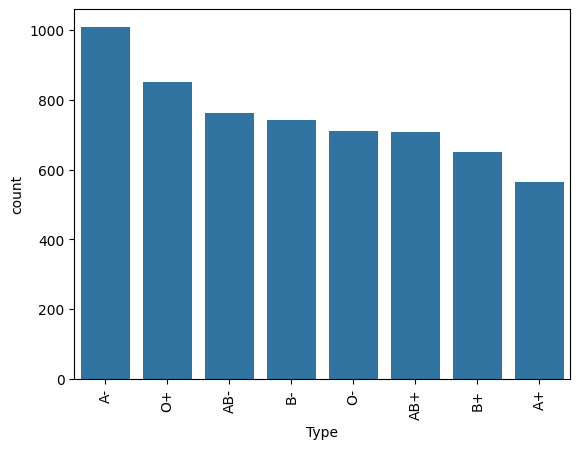

In [ ]:
# Create a DataFrame with file paths and labels
filepath = pd.Series(filepaths, name='Filepath').astype(str)
Labels = pd.Series(labels, name='Label')
data = pd.concat([filepath, Labels], axis=1)
data = data.sample(frac=1).reset_index(drop=True)
print(data.head(5))


counts = data.Label.value_counts()
sns.barplot(x=counts.index, y=counts)
plt.xlabel('Type')
plt.xticks(rotation=90)
plt.show()

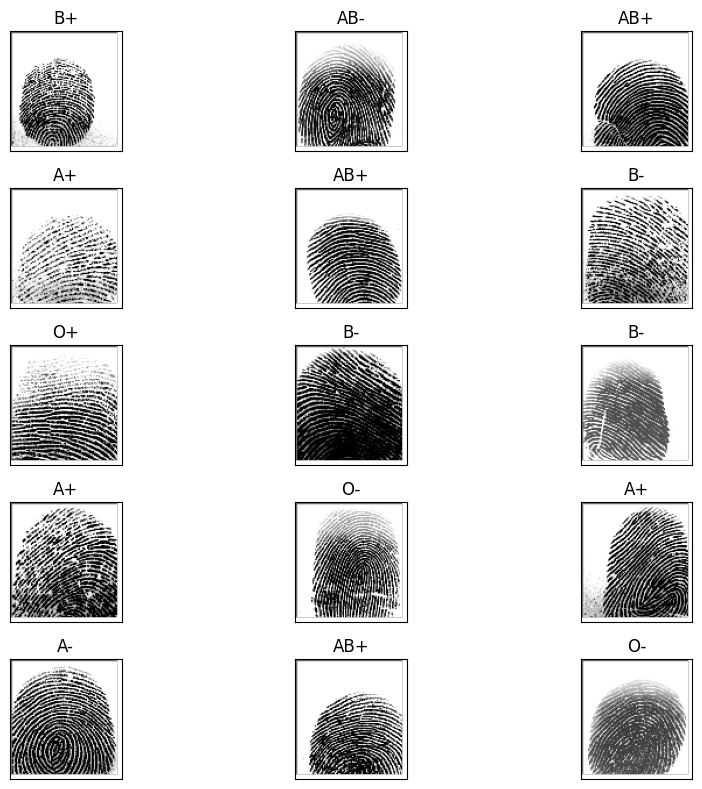

In [ ]:
# Split data
train, test = train_test_split(data, test_size=0.20, random_state=42)


fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(10, 8), subplot_kw={'xticks': [], 'yticks': []})
for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(data.Filepath[i]))
    ax.set_title(data.Label[i])
plt.tight_layout()
plt.show()

In [ ]:
# ImageDataGenerator for training and validation data
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train,
    x_col='Filepath',
    y_col='Label',
    target_size=(256, 256),
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42
)

valid_gen = train_datagen.flow_from_dataframe(
    dataframe=test,
    x_col='Filepath',
    y_col='Label',
    target_size=(256, 256),
    class_mode='categorical',
    batch_size=32,
    shuffle=False,
    seed=42
)

Found 4800 validated image filenames belonging to 8 classes.
Found 1200 validated image filenames belonging to 8 classes.


In [63]:
from tensorflow.keras.applications import VGG16

# Define the base pre-trained model
vgg16_base = VGG16(
    input_shape=(256, 256, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

vgg16_base.trainable = False

# Add layers for classification on top of VGG16
x = Dense(128, activation="relu")(vgg16_base.output)
x = Dense(128, activation="relu")(x)
outputs = Dense(8, activation='softmax')(x)

vgg16_model = Model(inputs=vgg16_base.input, outputs=outputs)

vgg16_model.compile(
    optimizer="adam",
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = vgg16_model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=0,
)

In [ ]:


pd.DataFrame(history.history)[['accuracy', 'val_accuracy']].plot()
plt.title("Accuracy")
plt.show()

pd.DataFrame(history.history)[['loss', 'val_loss']].plot()
plt.title("Loss")
plt.show()


results = vgg16_model.evaluate(valid_gen, verbose=0)
print(f"Test Loss: {results[0]:.5f}")
print(f"Test Accuracy: {results[1]*100:.2f}%")

# Predict labels for test data
pred = vgg16_model.predict(valid_gen)
pred = np.argmax(pred, axis=1)

# Map predicted labels
labels = train_gen.class_indices
labels = dict((v, k) for k, v in labels.items())
pred = [labels[k] for k in pred]

y_test = list(test.Label)
print(classification_report(y_test, pred))

KeyError: "None of [Index(['accuracy', 'val_accuracy'], dtype='object')] are in the [columns]"

In [ ]:
vgg16_model.save("bg-fe-default.h5")

In [ ]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.imagenet_utils import preprocess_input


class SafeDense(Dense):
    def __init__(self, *args, quantization_config=None, **kwargs):
        super().__init__(*args, **kwargs)


model_path = 'bg-fe-default.h5'
dataset_dir = 'dataset'
img_target_size = (256, 256)
CHUNK_SIZE = 500  


model = load_model(model_path, compile=False, custom_objects={'Dense': SafeDense})

class_names = sorted([d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d))])
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

all_file_paths = []
all_true_labels = []

print(f"Discovered classes ({len(class_names)}): {class_to_idx}")

for class_name in class_names:
    class_folder = os.path.join(dataset_dir, class_name)
    class_idx = class_to_idx[class_name]
    
    file_names = [f for f in os.listdir(class_folder) if f.lower().endswith(('.bmp', '.png', '.jpg', '.jpeg'))]
    for fn in file_names:
        all_file_paths.append(os.path.join(class_folder, fn))
        all_true_labels.append(class_idx)

total_images = len(all_file_paths)
all_true_labels = np.array(all_true_labels)

print(f"Found {total_images} total images across all directories.")
print(f"Processing dataset in batches of {CHUNK_SIZE} images...\n")

all_predictions = []
start_total_time = time.time()

num_chunks = int(np.ceil(total_images / CHUNK_SIZE))

for chunk_idx in range(num_chunks):
    start_idx = chunk_idx * CHUNK_SIZE
    end_idx = min((chunk_idx + 1) * CHUNK_SIZE, total_images)
    
    batch_paths = all_file_paths[start_idx:end_idx]
    current_batch_size = len(batch_paths)
    
    print(f"--- Processing Chunk {chunk_idx + 1}/{num_chunks} (Images {start_idx + 1} to {end_idx}) ---")
    
	
    t0 = time.time()
    images_list = []
    for p in batch_paths:
        img = image.load_img(p, target_size=img_target_size)
        img_arr = image.img_to_array(img)
        images_list.append(img_arr)
        
    X_chunk = np.array(images_list, dtype='float32')
    load_time = time.time() - t0
    
    # Preprocess in-memory batch
    X_chunk_preprocessed = preprocess_input(X_chunk)
    
    # Predict on the 500-image batch
    
    t1 = time.time()
    chunk_preds = model.predict(X_chunk_preprocessed, batch_size=32, verbose=1)
    predict_time = time.time() - t1
    
    all_predictions.append(chunk_preds)
    
    print(f"[CHUNK SUMMARY] Read: {load_time:.2f}s | Predict: {predict_time:.2f}s | Memory: {X_chunk.nbytes / (1024**2):.1f} MB\n")


predictions = np.vstack(all_predictions)
y_pred = np.argmax(predictions, axis=1)
total_execution_time = time.time() - start_total_time


#final
correct_count = np.sum(y_pred == all_true_labels)
accuracy = (correct_count / total_images) * 100

print("=" * 55)
print(f"                 FINAL EVALUATION RESULTS                 ")
print("=" * 26)
print(f" Average Throughput     : {total_images / total_execution_time:.2f} images/sec")
print(f" Total Elapsed Time     : {total_execution_time:.2f} seconds")
print(f" Correct Predictions    : {correct_count}")
print(f" Overall Model Accuracy : {accuracy:.2f}%")
print(f" Total Images Processed : {total_images}")
print("=" * 26 + "\n")


print("Classification Report:")
print(classification_report(all_true_labels, y_pred, target_names=class_names))


cm = confusion_matrix(all_true_labels, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix (Accuracy: {accuracy:.2f}%)')
plt.tight_layout()
plt.show()

I0000 00:00:1785657320.412297    4339 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


[INFO] Loading pre-trained model...


E0000 00:00:1785657324.120022    4339 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


[INFO] Discovered classes (8): {'A+': 0, 'A-': 1, 'AB+': 2, 'AB-': 3, 'B+': 4, 'B-': 5, 'O+': 6, 'O-': 7}
[INFO] Found 6000 total images across all directories.
[INFO] Processing dataset in batches of 500 images...

--- Processing Chunk 1/12 (Images 1 to 500) ---
16/16 ━━━━━━━━━━━━━━━━━━━━ 113s 7s/step
[CHUNK SUMMARY] Read: 0.76s | Predict: 113.90s | Memory: 375.0 MB

--- Processing Chunk 2/12 (Images 501 to 1000) ---
16/16 ━━━━━━━━━━━━━━━━━━━━ 124s 8s/step
[CHUNK SUMMARY] Read: 0.62s | Predict: 124.77s | Memory: 375.0 MB

--- Processing Chunk 3/12 (Images 1001 to 1500) ---
 6/16 ━━━━━━━━━━━━━━━━━━━━ 1:20 8s/step

KeyboardInterrupt: 